# Door / Window Segmentation trên ảnh 2D

Pipeline **Grounded-SAM**: kết hợp **Grounding DINO** (open-vocabulary object detection theo text prompt, không cần train lại — SOTA hiện tại cho zero-shot detection) với **SAM 2** (Segment Anything Model 2 của Meta, SOTA cho segmentation) để tạo mask chính xác từ bounding box.

- Bước 1: Grounding DINO detect vị trí "door" và "window" trong ảnh theo text prompt `"door. window."`.
- Bước 2: Bounding box được dùng làm prompt cho SAM 2 để sinh ra mask phân đoạn theo đúng hình dạng vật thể.
- Bước 3: Overlay mask + box + label lên ảnh gốc và lưu kết quả vào thư mục `outputs/`.

> Lưu ý: ban đầu thử YOLO-World nhưng confidence rất thấp trên các ảnh cửa/kính thực tế của bạn (đặc biệt cửa sổ có rèm). Grounding DINO cho kết quả ổn định và chính xác hơn nhiều trên đúng 3 ảnh test này nên notebook dùng model này.


In [1]:
%pip install -q ultralytics opencv-python matplotlib pillow transformers timm accelerate torch torchvision


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import SAM

INPUT_DIR = "window_door_picture"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TEXT_PROMPT = "door. window."   # mỗi lớp cách nhau bằng dấu chấm, đúng format Grounding DINO
# TEXT_PROMPT = "door."   # mỗi lớp cách nhau bằng dấu chấm, đúng format Grounding DINO
BOX_THRESHOLD = 0.5            # ngưỡng confidence giữ box
TEXT_THRESHOLD = 0.25           # ngưỡng khớp giữa box và text
NMS_IOU_THRES = 0.7             # gộp box trùng nhau trong cùng 1 nhãn
CROSS_LABEL_IOU_THRES = 0.7     # gộp box trùng nhau giữa 2 nhãn (VD: cửa có kính bị match cả "door" lẫn "window")

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")

image_paths = sorted(
    glob.glob(os.path.join(INPUT_DIR, "*.jpg"))
    + glob.glob(os.path.join(INPUT_DIR, "*.jpeg"))
    + glob.glob(os.path.join(INPUT_DIR, "*.png"))
)
print(f"Tìm thấy {len(image_paths)} ảnh, dùng device: {DEVICE}")
for p in image_paths:
    print(" -", p)


Tìm thấy 10 ảnh, dùng device: mps
 - window_door_picture/1785906131855_4877037092508209607_4877037092508209607_01358d5ceb004f830bb502669a2d5785.jpg
 - window_door_picture/1785906131877_4877037092508209607_4877037092508209607_08581c184b760fabf77989138a8703db.jpg
 - window_door_picture/1785906131892_4877037092508209607_4877037092508209607_a7a7a523f44e85a20f34e3be843aa5e2.jpg
 - window_door_picture/1785987113719_4877037092508209607_g8735503775779471187_f275eae651998a26b071568b1a4e9d7b.jpg
 - window_door_picture/1785987113733_4877037092508209607_g8735503775779471187_76031225a7c92fd6eb10966b669aff80.jpg
 - window_door_picture/1785987113744_4877037092508209607_g8735503775779471187_5be82217fe98517637bb9d51baa7a716.jpg
 - window_door_picture/1785987113755_4877037092508209607_g8735503775779471187_acc06fa2866dd6c2eb205f2c6864e674.jpg
 - window_door_picture/1785987113764_4877037092508209607_g8735503775779471187_add00ae9e031b160da1702453b780905.jpg
 - window_door_picture/1785987113772_487703709250

In [3]:
# Load model detect open-vocabulary (Grounding DINO) + model segment (SAM 2)
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

GDINO_MODEL_ID = "IDEA-Research/grounding-dino-base"
gdino_processor = AutoProcessor.from_pretrained(GDINO_MODEL_ID)
gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(GDINO_MODEL_ID).to(DEVICE)

segmenter = SAM("sam2.1_b.pt")


/Users/phuc/Phúc/VKSIT/3D-aligment/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 1182/1182 [00:00<00:00, 9689.34it/s]


In [4]:
CLASS_COLORS = {
    "door": (60, 180, 75),     # xanh lá
    "window": (255, 130, 0),   # cam
}


def canonical_label(text_label: str):
    l = text_label.lower()
    if "door" in l:
        return "door"
    if "window" in l:
        return "window"
    return None


def _iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter + 1e-9)


def detect_boxes(image_rgb: np.ndarray):
    """Grounding DINO detection -> box list đã gộp theo nhãn (door/window)."""
    pil_image = Image.fromarray(image_rgb)
    inputs = gdino_processor(images=pil_image, text=TEXT_PROMPT, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = gdino_model(**inputs)
    result = gdino_processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD,
        target_sizes=[pil_image.size[::-1]],
    )[0]

    boxes, scores, labels = [], [], []
    for box, score, text_label in zip(result["boxes"], result["scores"], result["labels"]):
        label = canonical_label(text_label)
        if label is not None:
            boxes.append(box.tolist())
            scores.append(float(score))
            labels.append(label)

    if not boxes:
        return np.zeros((0, 4)), np.array([]), np.array([])

    boxes, scores, labels = np.array(boxes), np.array(scores), np.array(labels)

    # 1) NMS trong cùng 1 nhãn (nhiều synonym có thể match cùng 1 vật thể)
    keep = []
    for label in np.unique(labels):
        idxs = np.where(labels == label)[0]
        xywh = [[x1, y1, x2 - x1, y2 - y1] for x1, y1, x2, y2 in boxes[idxs].tolist()]
        nms_idx = cv2.dnn.NMSBoxes(xywh, scores[idxs].tolist(), score_threshold=0.0, nms_threshold=NMS_IOU_THRES)
        keep.extend(idxs[np.array(nms_idx).flatten()])
    keep = np.array(keep)
    boxes, scores, labels = boxes[keep], scores[keep], labels[keep]

    # 2) Gộp box trùng nhau giữa 2 nhãn khác nhau, giữ box confidence cao hơn
    order = np.argsort(scores)[::-1]
    final = []
    for i in order:
        if all(_iou(boxes[i], boxes[j]) < CROSS_LABEL_IOU_THRES for j in final):
            final.append(i)
    final = np.array(final)
    return boxes[final], scores[final], labels[final]


def run_segmentation(image_path: str, out_dir: str):
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    overlay = image_bgr.copy()

    boxes, scores, labels = detect_boxes(image_rgb)
    detections = []

    if len(boxes) > 0:
        sam_result = segmenter.predict(image_bgr, bboxes=boxes, verbose=False)[0]
        masks = sam_result.masks.data.cpu().numpy() if sam_result.masks is not None else []

        for box, label, conf, mask in zip(boxes, labels, scores, masks):
            color = CLASS_COLORS.get(label, (0, 0, 255))

            mask_bool = mask.astype(bool)
            if mask_bool.shape[:2] != overlay.shape[:2]:
                mask_bool = cv2.resize(
                    mask_bool.astype(np.uint8),
                    (overlay.shape[1], overlay.shape[0]),
                    interpolation=cv2.INTER_NEAREST,
                ).astype(bool)
            overlay[mask_bool] = (
                0.5 * np.array(color) + 0.5 * overlay[mask_bool]
            ).astype(np.uint8)

            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)
            text = f"{label} {conf:.2f}"
            cv2.putText(
                overlay, text, (x1, max(y1 - 8, 15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2, cv2.LINE_AA,
            )
            detections.append({"label": label, "conf": float(conf), "box": box.tolist()})

    out_name = os.path.splitext(os.path.basename(image_path))[0] + "_segmented.jpg"
    out_path = os.path.join(out_dir, out_name)
    cv2.imwrite(out_path, overlay)
    return overlay, detections, out_path


/Users/phuc/Phúc/VKSIT/3D-aligment/.venv/lib/python3.14/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


1785906131855_4877037092508209607_4877037092508209607_01358d5ceb004f830bb502669a2d5785.jpg -> 2 object(s) detected, saved to outputs/1785906131855_4877037092508209607_4877037092508209607_01358d5ceb004f830bb502669a2d5785_segmented.jpg
    door: conf=0.60, box=[833.8052978515625, 652.5081787109375, 1366.7724609375, 2294.392333984375]
    door: conf=0.53, box=[215.4107666015625, 890.5335693359375, 390.6623840332031, 1730.1951904296875]
1785906131877_4877037092508209607_4877037092508209607_08581c184b760fabf77989138a8703db.jpg -> 1 object(s) detected, saved to outputs/1785906131877_4877037092508209607_4877037092508209607_08581c184b760fabf77989138a8703db_segmented.jpg
    door: conf=0.52, box=[282.9761047363281, 359.7711181640625, 887.754150390625, 2430.759033203125]
1785906131892_4877037092508209607_4877037092508209607_a7a7a523f44e85a20f34e3be843aa5e2.jpg -> 4 object(s) detected, saved to outputs/1785906131892_4877037092508209607_4877037092508209607_a7a7a523f44e85a20f34e3be843aa5e2_segmente

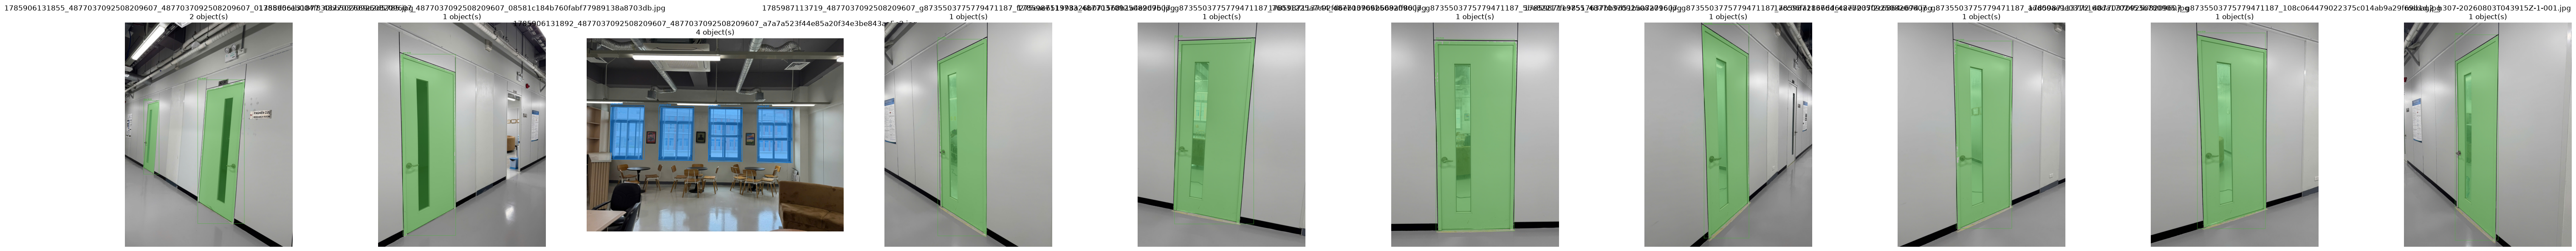

In [5]:
# Chạy pipeline trên toàn bộ ảnh và hiển thị kết quả
results = []
for path in image_paths:
    overlay, detections, out_path = run_segmentation(path, OUTPUT_DIR)
    results.append((path, overlay, detections, out_path))
    print(f"{os.path.basename(path)} -> {len(detections)} object(s) detected, saved to {out_path}")
    for d in detections:
        print(f"    {d['label']}: conf={d['conf']:.2f}, box={d['box']}")

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6))
if len(results) == 1:
    axes = [axes]
for ax, (path, overlay, detections, out_path) in zip(axes, results):
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{os.path.basename(path)}\n{len(detections)} object(s)")
    ax.axis("off")
plt.tight_layout()
plt.show()
